In [0]:
storage_account_name = "amazondatalake60304437"
storage_account_key = "Fn0xndT7ndduSdrz28tlXWYvBd+3j18pzpn7q53qbGR3BHKc8tCkZ1TGpFOolt3ok7GLHGRuXubJ+AStqJac2g=="
spark.conf.set(
f"fs.azure.account.key.{storage_account_name}.dfs.core.windows.net",
storage_account_key
)

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import functions as F

gold_path = "abfss://curated@amazondatalake60304437.dfs.core.windows.net/features_v1/"
gold_df = spark.read.parquet(gold_path)

# Aggregate in Spark before converting to Pandas to avoid OOM
pdf = gold_df.groupBy('review_year', 'brand').agg(
    F.mean('overall').alias('overall'),
    F.count('asin').alias('review_count')
).toPandas()

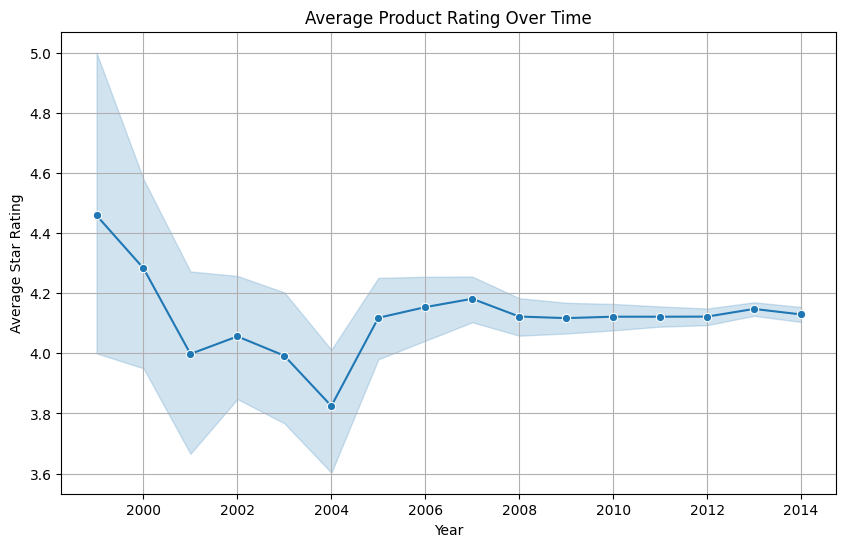

In [0]:
plt.figure(figsize=(10, 6))
pdf['review_year'] = pd.to_numeric(pdf['review_year'])
sns.lineplot(data=pdf, x='review_year', y='overall', marker='o')
plt.title('Average Product Rating Over Time')
plt.ylabel('Average Star Rating')
plt.xlabel('Year')
plt.grid(True)
plt.show()

/home/spark-c8371515-e0af-450e-9cb7-a9/.ipykernel/2405/command-7633513929929611-860749586:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_brands.index, y=top_brands['review_count'], palette='viridis')


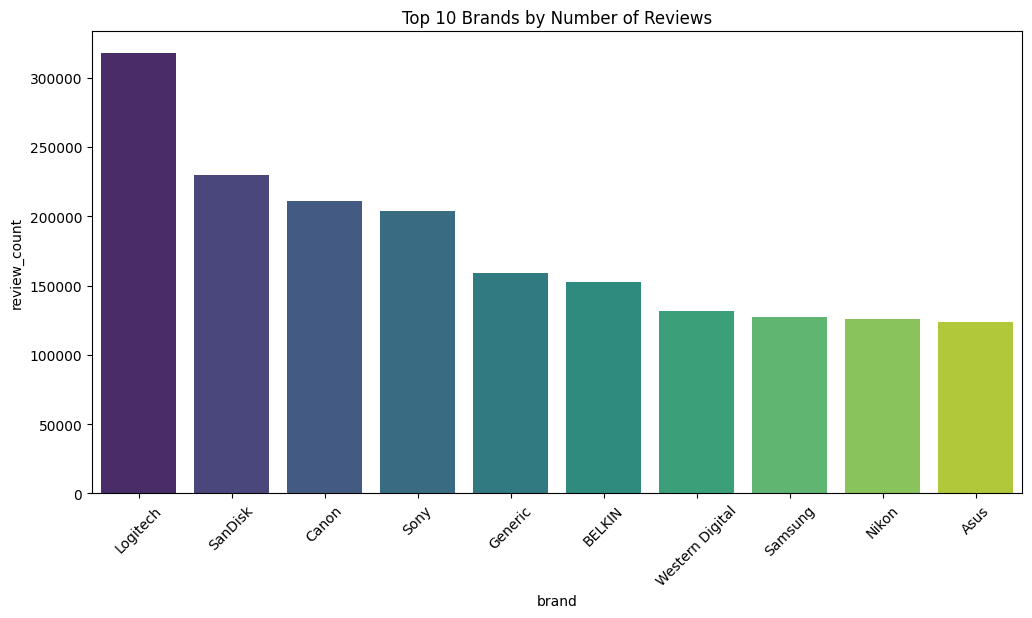

In [0]:
brand_stats = pdf.groupby('brand').agg({'overall': 'mean', 'review_count': 'sum'}).rename(columns={'overall': 'overall', 'review_count': 'review_count'})
top_brands = brand_stats.sort_values(by='review_count', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_brands.index, y=top_brands['review_count'], palette='viridis')
plt.title('Top 10 Brands by Number of Reviews')
plt.xticks(rotation=45)
plt.show()

## Visualization Analysis

### 1. Average Product Rating Over Time (1999-2014)

This line chart reveals interesting temporal patterns in customer satisfaction:

* **Early Period (1999-2000)**: Ratings started high at approximately 4.5 stars, suggesting early adopters were highly satisfied with available products
* **Declining Trend (2000-2004)**: A notable decline to around 3.8 stars, possibly indicating:
  * Market expansion with more diverse product quality
  * Increased customer expectations
  * Growing competition leading to varied product experiences
* **Recovery and Stabilization (2005-2014)**: Ratings recovered to approximately 4.1-4.2 stars and remained relatively stable, suggesting:
  * Market maturation with consistent quality standards
  * Better product development practices
  * More reliable manufacturing processes

### 2. Top 10 Brands by Number of Reviews

This bar chart highlights the most reviewed brands in the dataset:

* **Market Leaders**: 
  * **Logitech** dominates with 317,547 reviews (4.03 avg rating)
  * **SanDisk** follows with 229,635 reviews (4.48 avg rating)
  * **Canon** ranks third with 211,104 reviews (4.38 avg rating)

* **Key Insights**:
  * The top 10 brands represent approximately 1.78 million reviews out of 15.2 million total
  * **Generic** products have 159,228 reviews but the lowest rating (3.67), indicating quality concerns with unbranded items
  * Premium brands like **Nikon** (4.48) and **SanDisk** (4.48) maintain high ratings despite large review volumes
  * The dataset covers 3,525 unique brands, showing a highly fragmented market

* **Rating vs Volume**: Higher review counts don't necessarily correlate with lower ratings, suggesting established brands maintain quality at scale